# Interpretability Experiment

### Environment Setup

In [1]:
import sys
sys.path.insert(0, "../src")

import torch
import pandas as pd
from pathlib import Path

DEIT_CKPT       = "../checkpoints/deit_b_focal/best.pt"
SWIN_CKPT       = "../checkpoints/swin_t_focal/best.pt"
TEST_MANIFEST   = "../data/manifests/test.csv"
BBOX_CSV        = "../data/raw/BBox_List_2017_Official_NIH.csv"

OUTPUT_DIR = Path("../outputs/interpretability_notebook")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")
print(f"torch: {torch.__version__}")

device: cuda
torch: 2.12.0.dev20260405+cu128


### Load model (DeiT-B and Swin-T) by Timm

In [2]:
import timm
from models.deit_swin import _TIMM_NAMES

def load_model(model_name, ckpt_path, device):
    model = timm.create_model(_TIMM_NAMES[model_name], pretrained=False, num_classes=14)
    model.load_state_dict(torch.load(ckpt_path, map_location=device))
    return model.to(device).eval()

deit = load_model("deit_b", DEIT_CKPT, device)
swin = load_model("swin_t", SWIN_CKPT, device)

deit_params = sum(p.numel() for p in deit.parameters()) / 1e6
swin_params = sum(p.numel() for p in swin.parameters()) / 1e6ta
print(f"DeiT-B: {deit_params:.1f}M params")
print(f"Swin-T: {swin_params:.1f}M params")

/home/xsquare/miniconda3/envs/cs7643/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DeiT-B: 85.8M params
Swin-T: 27.5M params


### Build Clean Sample Index

We subset the test set to single-label GT images where both models' argmax prediction matches the GT label. This converts the multi-label problem into a clean single-label evaluation setting, ensuring heatmaps explain correct, unambiguous predictions.

In [4]:
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.transforms import InterpolationMode
from data import NIH_CHEST_XRAY_LABELS
LABEL_COLS   = list(NIH_CHEST_XRAY_LABELS)

# Val/test preprocessing matching (with ImageNet): Resize + ImageNet mean/std normalization.
_TRANSFORM = transforms.Compose([
    transforms.Resize((224, 224), interpolation=InterpolationMode.BICUBIC),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class _ImgDataset(Dataset):
    def __init__(self, paths):
        self.paths = paths
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, i):
        return _TRANSFORM(Image.open(self.paths[i]).convert("RGB"))

def build_clean_index(test_df, deit, swin, device, batch_size=64):
    single_df = test_df[test_df[LABEL_COLS].sum(axis=1) == 1].reset_index(drop=True)
    print(f"Single-label samples: {len(single_df)}")

    gt_idx = torch.tensor(single_df[LABEL_COLS].values, dtype=torch.float32).argmax(dim=1)

    loader = DataLoader(_ImgDataset(single_df["image_path"].tolist()),
                        batch_size=batch_size, num_workers=4, pin_memory=True)

    deit_preds, swin_preds = [], []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            deit_preds.append(torch.sigmoid(deit(batch)).argmax(dim=1).cpu())
            swin_preds.append(torch.sigmoid(swin(batch)).argmax(dim=1).cpu())

    ok = (torch.cat(deit_preds) == gt_idx) & (torch.cat(swin_preds) == gt_idx)
    clean_df = single_df[ok.numpy().astype(bool)].copy().reset_index(drop=True)

    def _gt_label(row):
        for col in LABEL_COLS:
            if row[col] == 1:
                return col

    clean_df["gt_label"] = clean_df.apply(_gt_label, axis=1)
    print(f"Clean samples (both argmax == GT): {len(clean_df)}")
    for label in LABEL_COLS:
        n = (clean_df["gt_label"] == label).sum()
        if n > 0:
            print(f"{label:22s}: {n}")
    return clean_df

test_df = pd.read_csv(TEST_MANIFEST)
clean_index = build_clean_index(test_df, deit, swin, device)

Single-label samples: 8002


Clean samples (both argmax == GT): 2701
Atelectasis           : 218
Cardiomegaly          : 62
Effusion              : 588
Infiltration          : 1543
Mass                  : 107
Nodule                : 44
Pneumothorax          : 106
Edema                 : 1
Emphysema             : 28
Fibrosis              : 3
Pleural_Thickening    : 1


In [5]:
from interpretability import AttentionRollout, GradCAM, overlay_heatmap, pointing_game, trim_border

rollout_fn = AttentionRollout(deit)
deit_gcam_fn = GradCAM(deit, deit.blocks[-1], skip_first_token=True)
swin_gcam_fn = GradCAM(swin, swin.layers[-1])

print(f"AttentionRollout: hooking {len(deit.blocks)} attention layers in DeiT-B")

AttentionRollout: hooking 12 attention layers in DeiT-B


### Single Image Demo
Visualize single sample image first

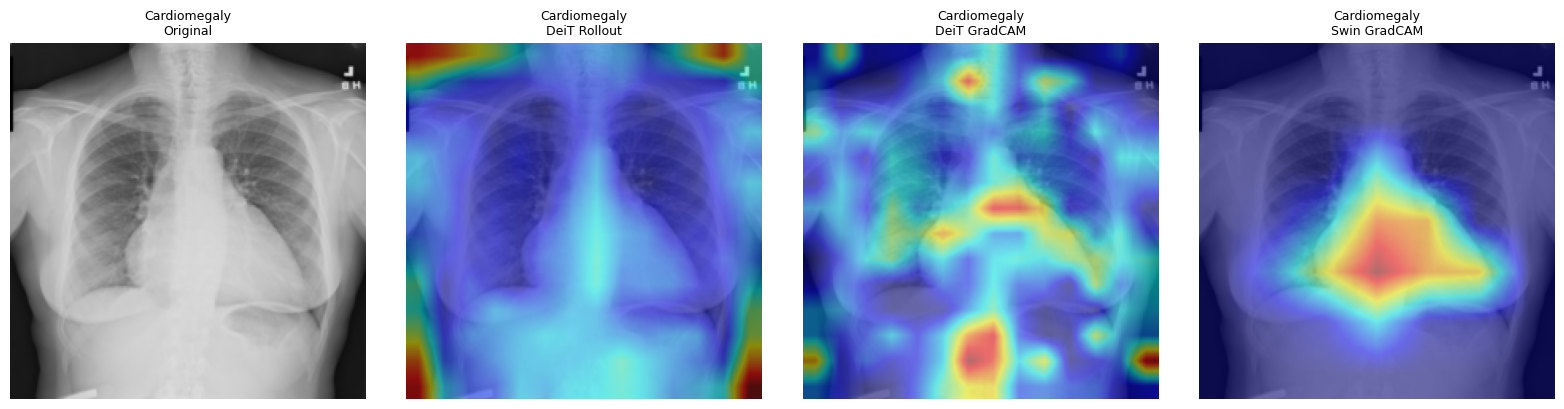

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

LABEL_TO_IDX = {label: i for i, label in enumerate(LABEL_COLS)}

sample = clean_index[clean_index["gt_label"] == "Cardiomegaly"].iloc[0]
class_idx = LABEL_TO_IDX["Cardiomegaly"]

def load_image(image_path, device):
    img = Image.open(image_path).convert("RGB")
    tensor = _TRANSFORM(img).unsqueeze(0).to(device)  # (1,3,224,224)
    gray = np.array(img.convert("L").resize((224, 224))) / 255.0
    return tensor, gray.astype(np.float32)  # gray: (224,224) 0~1

tensor, gray = load_image(sample["image_path"], device)

hm_rollout = rollout_fn(tensor)
hm_deit_cam = deit_gcam_fn(tensor, class_idx)
hm_swin_cam = swin_gcam_fn(tensor, class_idx)

deit_gcam_fn.model.zero_grad(set_to_none=True)
swin_gcam_fn.model.zero_grad(set_to_none=True)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (title, img) in zip(axes, [
    ("Original", gray),
    ("DeiT Rollout", overlay_heatmap(gray, hm_rollout)),
    ("DeiT GradCAM", overlay_heatmap(gray, hm_deit_cam)),
    ("Swin GradCAM", overlay_heatmap(gray, hm_swin_cam)),
]):
    ax.imshow(img, cmap="gray" if img.ndim == 2 else None, vmin=0, vmax=1)
    ax.set_title(f"Cardiomegaly\n{title}", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()


### Bounding Box Evaluation
Few of the sample have bounding box annotation, we can visualize how the feature/attention map align with the bounding box with each model.

In [13]:
bbox_df = pd.read_csv(BBOX_CSV, header=0).iloc[:, :6]
bbox_df.columns = ["image_name", "label", "x", "y", "w", "h"]

merged = bbox_df[bbox_df["image_name"].isin(set(clean_index["image_name"]))].merge(
    clean_index[["image_name", "image_path", "gt_label"]], on="image_name", how="inner"
)
merged = merged[merged["label"] == merged["gt_label"]]

print("Bbox samples available per disease (after clean index filter):")
print(merged["label"].value_counts().to_string())

Bbox samples available per disease (after clean index filter):
label
Atelectasis     19
Cardiomegaly    16
Effusion        16
Mass             8
Pneumothorax     6
Nodule           2


In [ ]:
PRIORITY_DISEASES = ["Atelectasis", "Cardiomegaly", "Effusion", "Mass", "Pneumothorax", "Nodule"]

In [27]:
ROLLOUT_BORDER = 16

In [30]:
SCALE = 224 / 1024

def bbox_to_mask(x, y, w, h):
    mask = np.zeros((224, 224), dtype=np.float32)
    x1, y1 = max(0, int(x * SCALE)), max(0, int(y * SCALE))
    x2, y2 = min(224, int((x + w) * SCALE)), min(224, int((y + h) * SCALE))
    mask[y1:y2, x1:x2] = 1.0
    return mask

def compute_iou(heatmap, gt_mask):
    pred = (heatmap >= 0.5).astype(np.float32)
    intersection = (pred * gt_mask).sum()
    union = np.clip(pred + gt_mask, 0, 1).sum()
    return float(intersection / (union + 1e-8))

def bbox_attention_ratio(heatmap, gt_mask):
    inside = float(heatmap[gt_mask > 0].mean()) if gt_mask.sum() > 0 else 0.0
    return inside / (float(heatmap.mean()) + 1e-8)

In [32]:
N_SAMPLES = 10

records = []
for disease in PRIORITY_DISEASES:
    samples = merged[merged["label"] == disease].head(N_SAMPLES)
    if samples.empty:
        print(f"[{disease}] no clean bbox samples")
        continue
    class_idx = LABEL_TO_IDX[disease]
    for _, row in samples.iterrows():
        tensor, gray = load_image(row["image_path"], device)
        gt_mask = bbox_to_mask(row["x"], row["y"], row["w"], row["h"])
        hm_r  = rollout_fn(tensor)
        hm_dg = deit_gcam_fn(tensor, class_idx)
        hm_sg = swin_gcam_fn(tensor, class_idx)
        deit_gcam_fn.model.zero_grad(set_to_none=True)
        swin_gcam_fn.model.zero_grad(set_to_none=True)
        records.append({
            "disease": disease,
            "iou_rollout":   compute_iou(hm_r,  gt_mask),
            "iou_deit_cam":  compute_iou(hm_dg, gt_mask),
            "iou_swin_cam":  compute_iou(hm_sg, gt_mask),
            "ar_rollout":    bbox_attention_ratio(hm_r,  gt_mask),
            "ar_deit_cam":   bbox_attention_ratio(hm_dg, gt_mask),
            "ar_swin_cam":   bbox_attention_ratio(hm_sg, gt_mask),
            "pg_rollout":    pointing_game(hm_r,  gt_mask, border=ROLLOUT_BORDER),
            "pg_deit_cam":   pointing_game(hm_dg, gt_mask, border=0),
            "pg_swin_cam":   pointing_game(hm_sg, gt_mask, border=0),
        })

results_df = pd.DataFrame(records)
results_df.groupby("disease").mean().round(3)

,iou_rollout,iou_deit_cam,iou_swin_cam,ar_rollout,ar_deit_cam,ar_swin_cam,pg_rollout,pg_deit_cam,pg_swin_cam
disease,,,,,,,,,
Atelectasis,0.0,0.000,0.180,0.685,1.817,3.961,0.0,0.000,0.3
Cardiomegaly,0.0,0.159,0.615,0.780,1.327,4.790,0.0,0.600,1.0
Effusion,0.0,0.012,0.136,0.682,1.383,2.654,0.0,0.000,0.2
Mass,0.0,0.029,0.236,0.712,2.676,3.608,0.0,0.125,0.5
Nodule,0.0,0.000,0.014,0.408,2.001,1.891,0.0,0.000,0.0
Pneumothorax,0.0,0.071,0.004,0.604,2.665,1.270,0.0,0.167,0.0


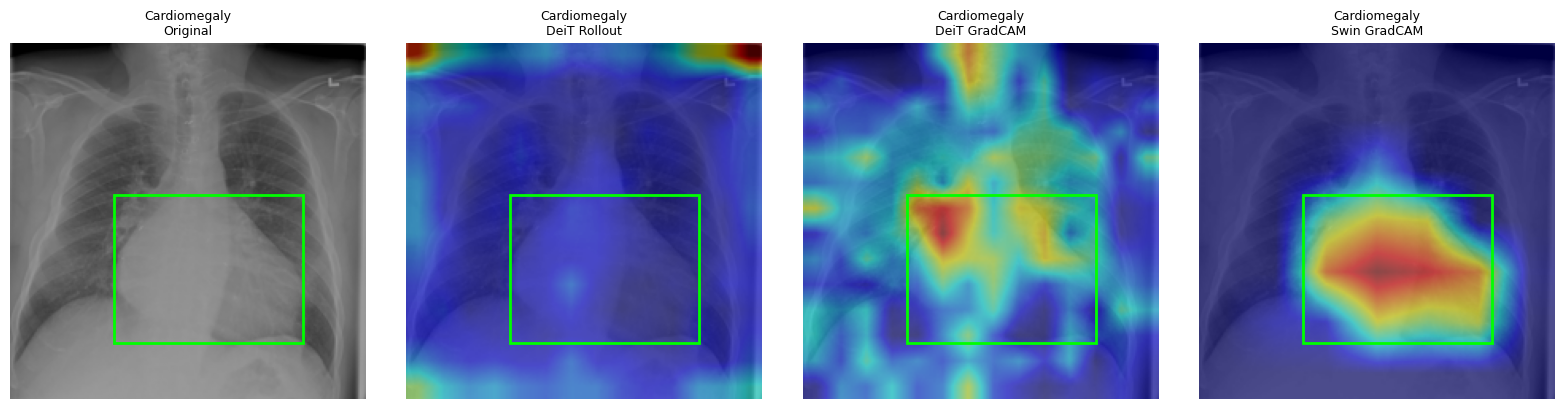

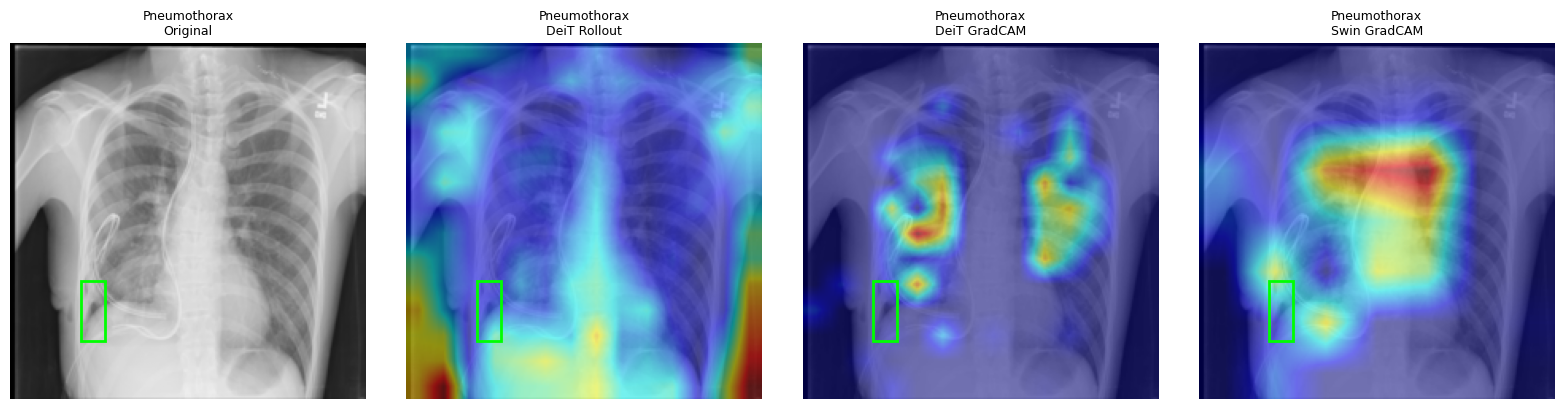

In [34]:
import matplotlib.patches as patches

for disease, sample_idx in [("Cardiomegaly", 0), ("Pneumothorax", 0)]:
    row = merged[merged["label"] == disease].iloc[sample_idx]
    class_idx = LABEL_TO_IDX[disease]
    tensor, gray = load_image(row["image_path"], device)
    gt_mask = bbox_to_mask(row["x"], row["y"], row["w"], row["h"])

    hm_r  = rollout_fn(tensor)
    hm_dg = deit_gcam_fn(tensor, class_idx)
    hm_sg = swin_gcam_fn(tensor, class_idx)
    deit_gcam_fn.model.zero_grad(set_to_none=True)
    swin_gcam_fn.model.zero_grad(set_to_none=True)

    ys, xs = np.where(gt_mask > 0)
    x1, x2, y1, y2 = xs.min(), xs.max(), ys.min(), ys.max()

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    for ax, (title, img) in zip(axes, [
        ("Original",     gray),
        ("DeiT Rollout", overlay_heatmap(gray, hm_r)),
        ("DeiT GradCAM", overlay_heatmap(gray, hm_dg)),
        ("Swin GradCAM", overlay_heatmap(gray, hm_sg)),
    ]):
        ax.imshow(img, cmap="gray" if img.ndim == 2 else None, vmin=0, vmax=1)
        ax.add_patch(patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                        linewidth=2, edgecolor="lime", facecolor="none"))
        ax.set_title(f"{disease}\n{title}", fontsize=9)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

### Per-label Average Heatmap
We calculated heatmaps for all samples of each label in clean_index and then averaged them to see the model's "general attention pattern" for each disease. Labels with more samples (1543 infiltration samples) were statistically the most reliable.

[Atelectasis] 0/218...
[Atelectasis] 100/218...
[Atelectasis] 200/218...


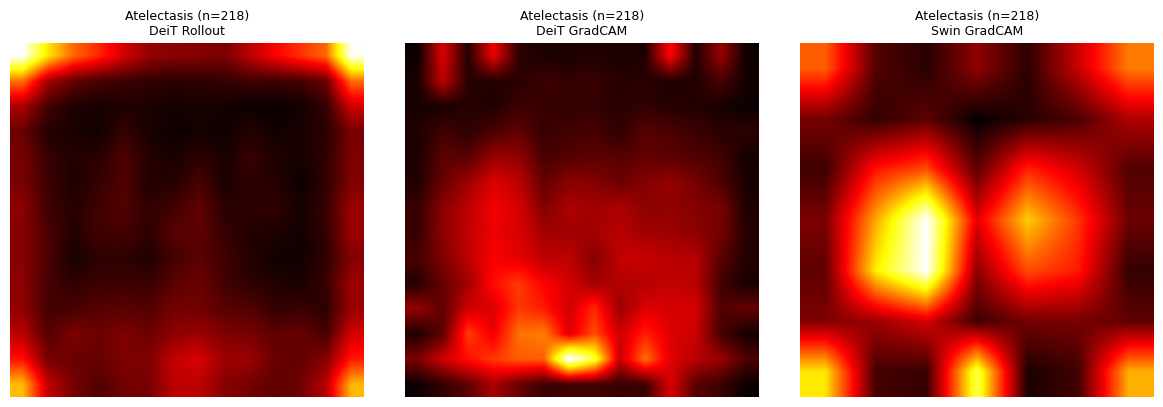

[Cardiomegaly] 0/62...


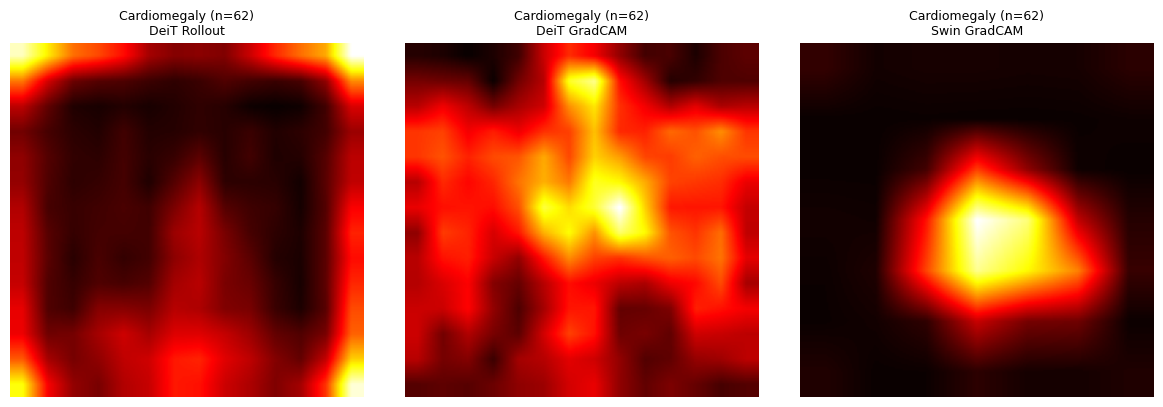

[Effusion] 0/588...
[Effusion] 100/588...
[Effusion] 200/588...
[Effusion] 300/588...
[Effusion] 400/588...
[Effusion] 500/588...


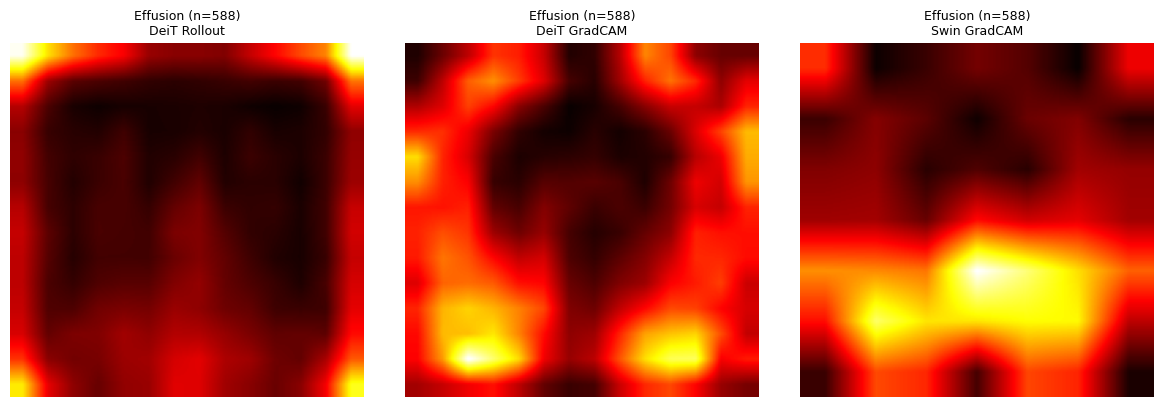

[Infiltration] 0/1543...
[Infiltration] 100/1543...
[Infiltration] 200/1543...
[Infiltration] 300/1543...
[Infiltration] 400/1543...
[Infiltration] 500/1543...
[Infiltration] 600/1543...
[Infiltration] 700/1543...
[Infiltration] 800/1543...
[Infiltration] 900/1543...
[Infiltration] 1000/1543...
[Infiltration] 1100/1543...
[Infiltration] 1200/1543...
[Infiltration] 1300/1543...
[Infiltration] 1400/1543...
[Infiltration] 1500/1543...


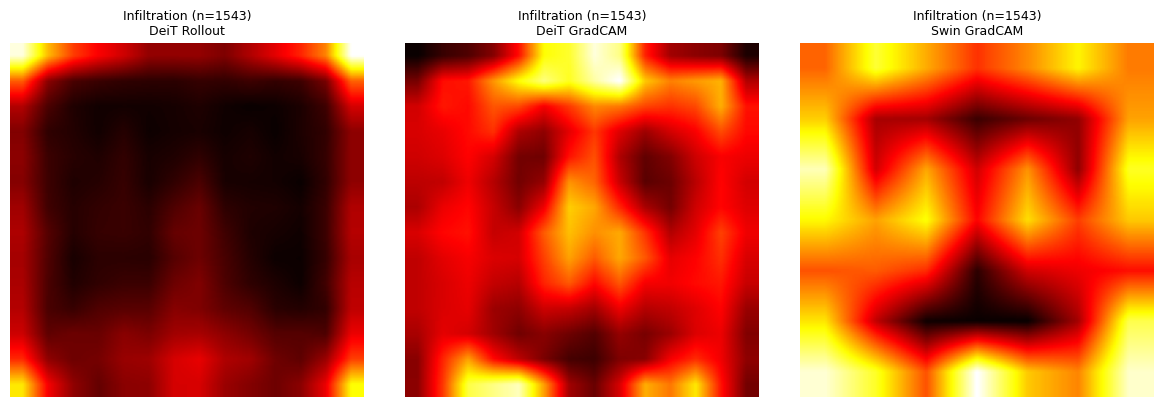

[Mass] 0/107...
[Mass] 100/107...


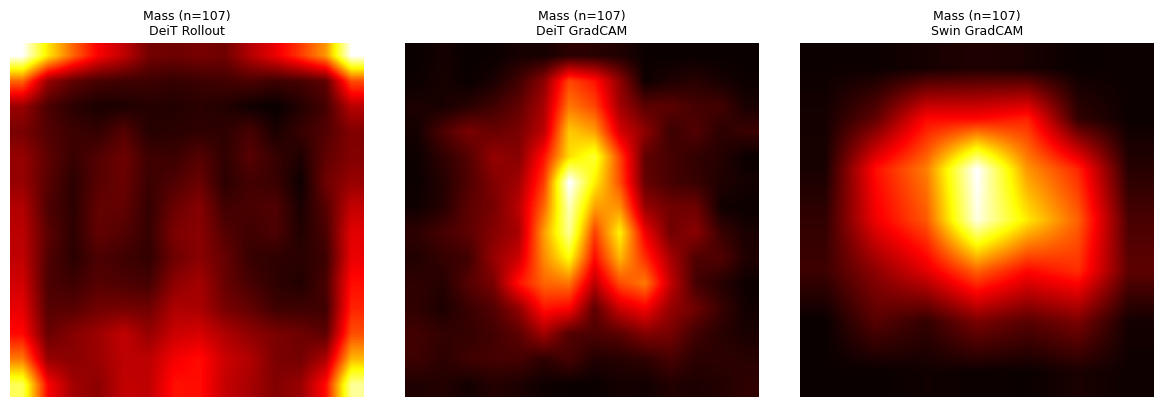

[Nodule] 0/44...


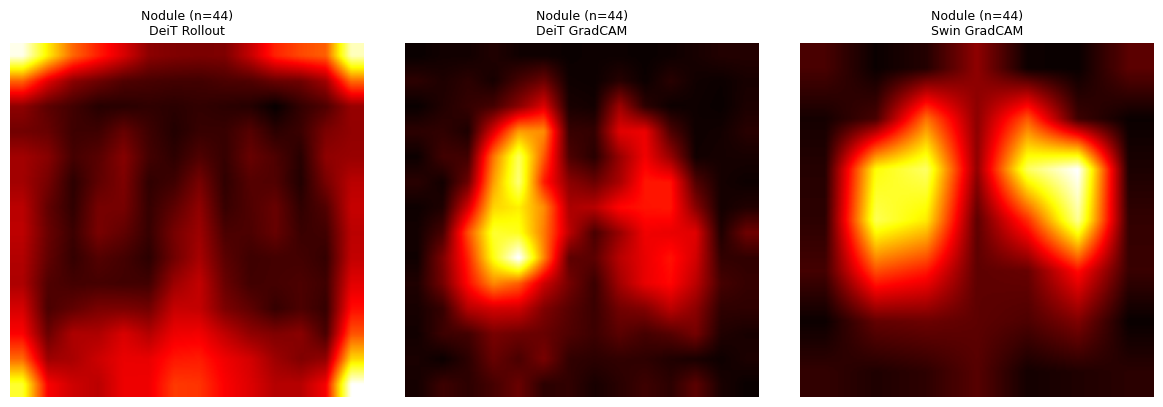

[Pneumothorax] 0/106...
[Pneumothorax] 100/106...


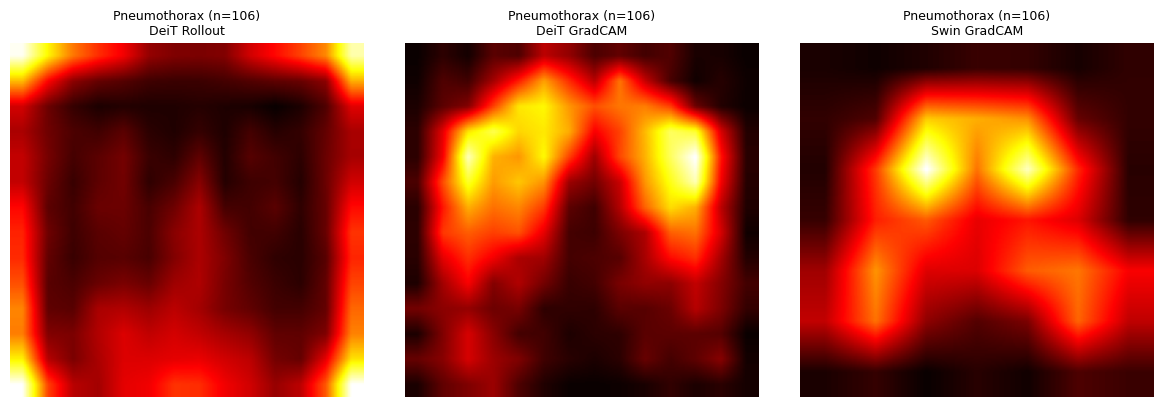

[Edema] 0/1...


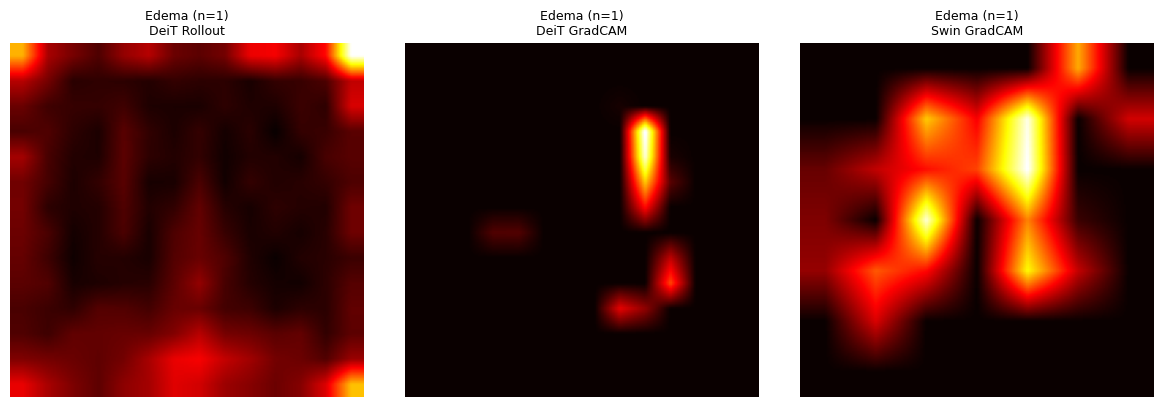

[Emphysema] 0/28...


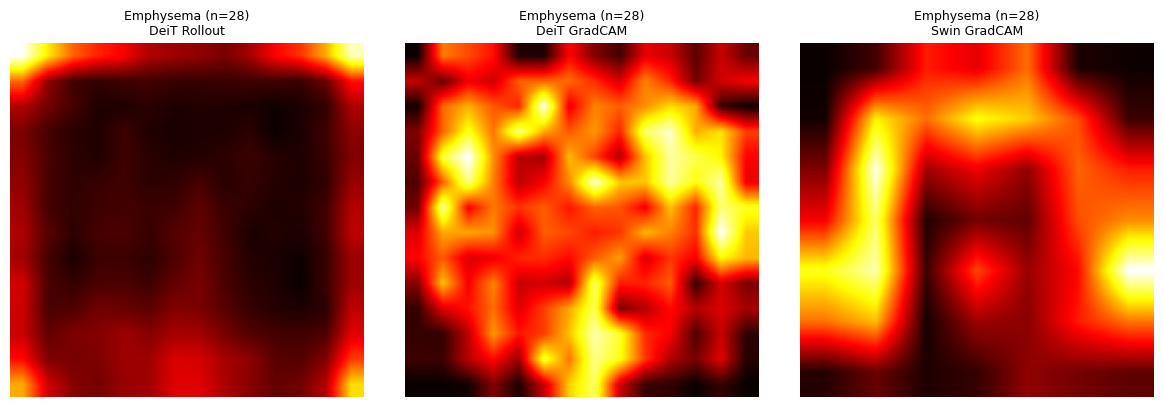

[Fibrosis] 0/3...


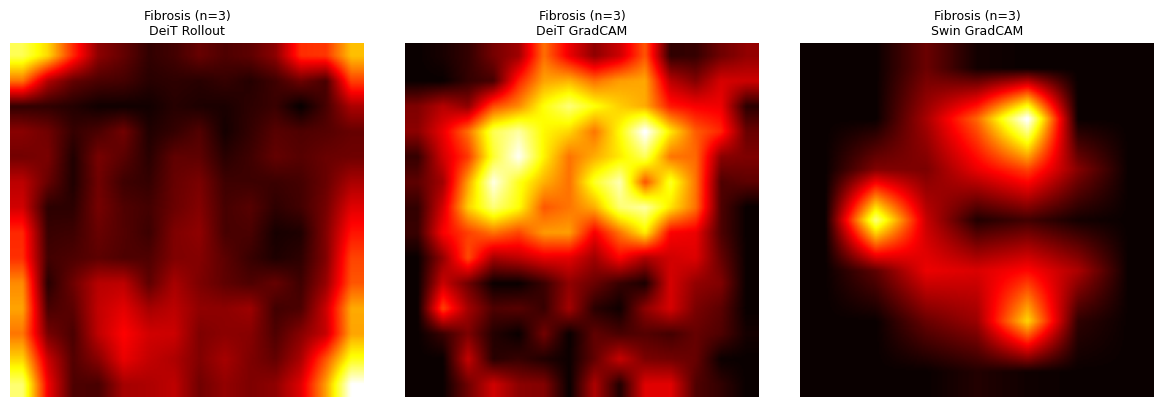

[Pleural_Thickening] 0/1...


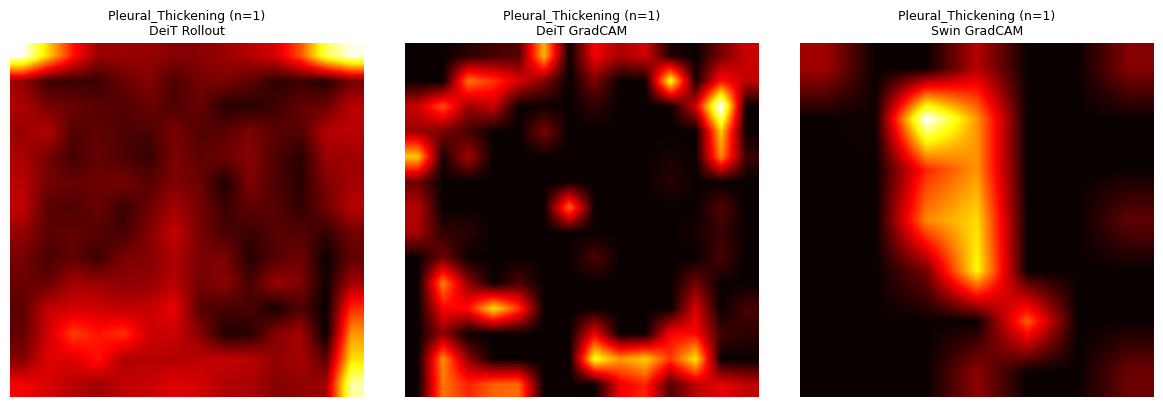

In [37]:
avg_dir = Path("../outputs/interpretability_notebook/avg_heatmaps")
avg_dir.mkdir(parents=True, exist_ok=True)

def norm(x):
    return (x - x.min()) / (x.max() - x.min() + 1e-8)

for label in LABEL_COLS:
    label_df = clean_index[clean_index["gt_label"] == label]
    n = len(label_df)
    if n == 0:
        continue

    class_idx = LABEL_TO_IDX[label]
    acc_r = acc_dg = acc_sg = None

    for idx, (_, row) in enumerate(label_df.iterrows()):
        if idx % 100 == 0:
            print(f"[{label}] {idx}/{n}...")
        tensor, _ = load_image(row["image_path"], device)
        hm_r  = rollout_fn(tensor)
        hm_dg = deit_gcam_fn(tensor, class_idx)
        hm_sg = swin_gcam_fn(tensor, class_idx)
        deit_gcam_fn.model.zero_grad(set_to_none=True)
        swin_gcam_fn.model.zero_grad(set_to_none=True)
        if device.type == "cuda" and idx % 50 == 0:
            torch.cuda.empty_cache()

        if acc_r is None:
            acc_r, acc_dg, acc_sg = hm_r.copy(), hm_dg.copy(), hm_sg.copy()
        else:
            acc_r += hm_r; acc_dg += hm_dg; acc_sg += hm_sg

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    for ax, (title, hm) in zip(axes, [
        ("DeiT Rollout", norm(acc_r / n)),
        ("DeiT GradCAM", norm(acc_dg / n)),
        ("Swin GradCAM", norm(acc_sg / n)),
    ]):
        ax.imshow(hm, cmap="hot", vmin=0, vmax=1)
        ax.set_title(f"{label} (n={n})\n{title}", fontsize=9)
        ax.axis("off")
    plt.tight_layout()
    plt.savefig(avg_dir / f"avg_{label}.png", dpi=150, bbox_inches="tight")
    plt.show()

In [ ]:
rollout_fn.remove_hooks()
deit_gcam_fn.remove_hooks()
swin_gcam_fn.remove_hooks()